# 02. Data Understanding Berita Detik.com

Notebook ini khusus untuk tahap **Data Understanding** pada dataset berita hasil crawling (`dataset_detik.csv`).
Tujuannya adalah memahami struktur data, memeriksa kualitas data (missing value & duplikasi), serta menganalisis distribusi kelas dan statistik teks.

## 1. Import Library
Mengimpor library yang diperlukan untuk manipulasi dan visualisasi data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

## 2. Membaca Dataset
Membaca file `dataset_detik.csv` hasil tahap crawling.

In [2]:
df = pd.read_csv("dataset_detik.csv")

print("Ukuran Dataset:", df.shape)
print("Daftar Kolom  :", df.columns.tolist())
display(df.head())

Ukuran Dataset: (200, 4)
Daftar Kolom  : ['id', 'isi_berita', 'label', 'url']


,id,isi_berita,label,url
0,SP001,Profil Desak Made Peraih Emas Keempat RI: Kena...,sport,https://sport.detik.com/sport-lain/d-8686722/p...
1,SP002,"Gacor di Asian Games, Leo/Daniel Kini Bidik Tu...",sport,https://sport.detik.com/raket/d-8686185/gacor-...
2,SP003,Asian Games 2026: Desak Made Raih Emas Keempat...,sport,https://sport.detik.com/sport-lain/d-8686648/a...
3,SP004,"Panjat Tebing Buru Medali, Yenni Wahid: Aditya...",sport,https://sport.detik.com/sport-lain/d-8686152/p...
4,SP005,Mau Nonton FIA Rallycross World Cup Indonesia?...,sport,https://sport.detik.com/sportstyle/d-8686158/m...


## 3. Struktur dan Tipe Data
Melihat ringkasan tipe data dan memastikan tidak ada nilai kosong (missing values).

In [3]:
print("--- Informasi Dataset ---")
df.info()

print("\n--- Pengecekan Missing Value ---")
print(df.isnull().sum())

--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          200 non-null    object
 1   isi_berita  200 non-null    object
 2   label       200 non-null    object
 3   url         200 non-null    object
dtypes: object(4)
memory usage: 6.4+ KB

--- Pengecekan Missing Value ---
id            0
isi_berita    0
label         0
url           0
dtype: int64


## 4. Pemeriksaan Duplikasi Data
Memeriksa apakah terdapat URL atau isi berita yang terduplikasi.

In [4]:
print("Jumlah Duplikat URL       :", df["url"].duplicated().sum())
print("Jumlah Duplikat Isi Berita:", df["isi_berita"].duplicated().sum())

Jumlah Duplikat URL       : 0
Jumlah Duplikat Isi Berita: 0


## 5. Distribusi Label
Melihat keseimbangan data antara kategori `sport` dan `finance`.

Distribusi Label:
 label
sport      100
finance    100
Name: count, dtype: int64


C:\Users\ELVITA\AppData\Local\Temp\ipykernel_23076\2174667711.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=distribusi.index, y=distribusi.values, palette=["#3498db", "#e74c3c"])


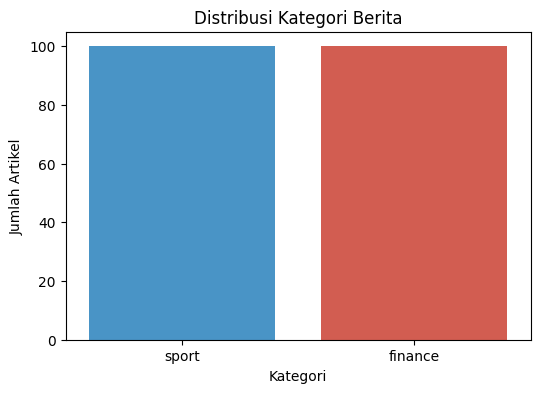

In [5]:
distribusi = df["label"].value_counts()
print("Distribusi Label:\n", distribusi)

# Visualisasi Bar Chart Distribusi Label
plt.figure(figsize=(6, 4))
sns.barplot(x=distribusi.index, y=distribusi.values, palette=["#3498db", "#e74c3c"])
plt.title("Distribusi Kategori Berita")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Artikel")
plt.show()

## 6. Analisis Statistik Panjang Teks
Menghitung panjang karakter dan jumlah kata pada isi berita per kategori.

Statistik Panjang Karakter per Kategori:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
finance,100.0,2833.23,1257.044641,392.0,2040.25,2715.5,3656.25,6836.0
sport,100.0,2507.95,911.469347,443.0,1916.50,2355.0,2908.00,6331.0



Statistik Jumlah Kata per Kategori:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
finance,100.0,389.70,168.159046,59.0,281.0,381.5,504.25,884.0
sport,100.0,363.58,126.589624,69.0,282.0,351.5,419.75,874.0


C:\Users\ELVITA\AppData\Local\Temp\ipykernel_23076\3593138865.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y="jumlah_kata", data=df, palette="Set2")


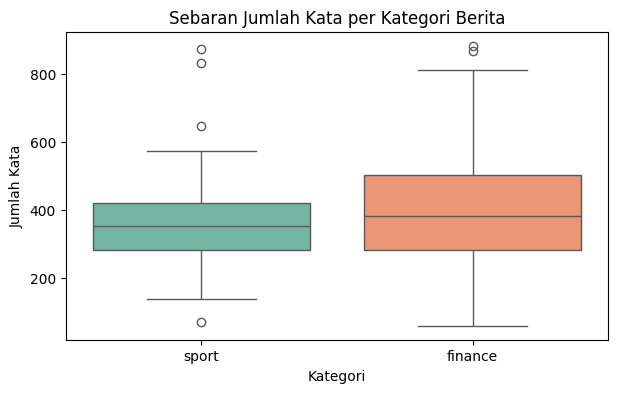

In [6]:
# Hitung jumlah karakter dan jumlah kata
df["panjang_karakter"] = df["isi_berita"].astype(str).apply(len)
df["jumlah_kata"] = df["isi_berita"].astype(str).apply(lambda x: len(x.split()))

print("Statistik Panjang Karakter per Kategori:")
display(df.groupby("label")["panjang_karakter"].describe())

print("\nStatistik Jumlah Kata per Kategori:")
display(df.groupby("label")["jumlah_kata"].describe())

# Visualisasi Boxplot Panjang Kata
plt.figure(figsize=(7, 4))
sns.boxplot(x="label", y="jumlah_kata", data=df, palette="Set2")
plt.title("Sebaran Jumlah Kata per Kategori Berita")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Kata")
plt.show()

## 7. Sampel Isi Berita per Kategori

In [7]:
print("=== Contoh Berita Sport ===")
sample_sport = df[df["label"] == "sport"].iloc[0]
print(f"ID  : {sample_sport['id']}")
print(f"Teks: {sample_sport['isi_berita'][:300]}...\n")

print("=== Contoh Berita Finance ===")
sample_finance = df[df["label"] == "finance"].iloc[0]
print(f"ID  : {sample_finance['id']}")
print(f"Teks: {sample_finance['isi_berita'][:300]}...")

=== Contoh Berita Sport ===
ID  : SP001
Teks: Profil Desak Made Peraih Emas Keempat RI: Kenal Panjat Tebing karena Bibi Mercy Raya - detikSport Rabu, 30 Sep 2026 20:15 WIB Jakarta - Desak Made Rita Kusuma Dewi kembali bikin bangga Indonesia. Ia menjadi atlet tercepat se-Asia setelah mempertahankan medali emasnya di Asian Games 2026 Aichi-Nagoya...

=== Contoh Berita Finance ===
ID  : FN001
Teks: Batas Penghasilan Tidak Kena Pajak Mau Dinaikkan Herdi Alif Al Hikam - detikFinance Rabu, 30 Sep 2026 20:30 WIB ... Tautan telah disalin Jakarta - Pemerintah membuka peluang untuk merevisi ambang batas Penghasilan Tidak Kena Pajak (PTKP). Artinya, bisa jadi batas penghasilan yang tidak kena pajak bi...
